# Waste Collection EDA and Statistical Tests (Updated for Case Study Alignment)

This notebook is tailored to the **Urban Waste Collection Optimization** case study for the **Region of Waterloo**.

## Why this notebook was updated
The statistical tests are now aligned with the business problem identified through the **Toyota Business Practice (TBP)** method:

- **TBP Step 1 – Problem:** Static scheduling does not adapt to changing waste demand across municipalities.
- **TBP Step 3 – Target:** Improve service reliability and reduce overflow risk.
- **TBP Step 4 – Root Cause:** Waste demand varies by municipality, service type, and housing structure.
- **TBP Step 5 – Countermeasure:** AI-driven demand-responsive routing.

## Aligned variables used in this notebook
### Test 1 – Welch's t-test
- **Independent Variable:** `GarbageServiceType`
- **Dependent Variable:** `WasteBagLimit`

### Test 2 – Chi-square test of independence
- **Variable 1:** `Municipality`
- **Variable 2:** `GarbageServiceType`

### Test 3 – Pearson correlation and simple linear regression
- **Independent Variable:** `NumberOfUnits`
- **Dependent Variable:** `WasteBagLimit`

These variables directly support the case study argument that **waste demand and service structure vary across the region**, which is why static routing is inefficient and AI-based optimization is a better countermeasure.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = r"/mnt/data/Waste_Management_Collection_Addresses.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (263929, 28)


In [2]:
# Show columns
pd.DataFrame({"Column": df.columns, "Dtype": df.dtypes.astype(str).values})


,Column,Dtype
0,X,float64
1,Y,float64
2,OBJECTID,int64
3,FullAddressWithSettlement,object
4,UnitNumber,object
5,AddressNumber,object
6,FullStreetName,object
7,Settlement,object
8,Municipality,object
9,GarbageServiceType,object


## 1. Quick dataset overview

In [3]:
display(df.head())
display(df.describe(include="all").transpose().head(15))


,X,Y,OBJECTID,FullAddressWithSettlement,UnitNumber,AddressNumber,FullStreetName,Settlement,Municipality,GarbageServiceType,BIA,NumberOfUnits,GarbagePickUpDayCode,RecyclingPickUpDayCode,GreenBinPickUpDayCode,LargeItemPickUpDayCode,YardWastePickUpDayCode,WasteBagLimit,BulkyItemBagLimit,RecycleService,RecycleCartDay,RecycleCartCollectionLocation,GreenCartAvailable,GreenCartDay,WasteExemptionID,WasteParcelRMWID,ROWRecycle,GlobalID
0,555469.7763,4.800863e+06,2,"8 Water St S, Cambridge",NaN,8,Water St S,Cambridge,Cambridge,Regional Pick Up,Yes,0.0,8W,5W,7R,7R,7R,10,0,NaN,NaN,NaN,NaN,NaN,NaN,WMP81334,Yes,{AE4C0320-C693-43D2-8303-3A6A0CB7F0C1}
1,545299.9851,4.802164e+06,68,"2R-155 Thomas Slee Dr, Kitchener",2R,155,Thomas Slee Dr,Kitchener,Kitchener,Private Molok Pick Up - Exemption,No,40.0,7R,7R,7R,7R,7R,0,0,Molok (Private),Not Applicable,NaN,No,Not Applicable,100414.0,WMP19027,No,{AE635343-C9F4-4AA2-9937-0A32A6B40507}
2,545348.8873,4.802135e+06,69,"3F-155 Thomas Slee Dr, Kitchener",3F,155,Thomas Slee Dr,Kitchener,Kitchener,Private Molok Pick Up - Exemption,No,40.0,7R,7R,7R,7R,7R,0,0,Molok (Private),Not Applicable,NaN,No,Not Applicable,100414.0,WMP19027,No,{269F36DD-F248-4691-B61B-CEC6A2ED7C60}
3,545308.1834,4.802158e+06,70,"2M-155 Thomas Slee Dr, Kitchener",2M,155,Thomas Slee Dr,Kitchener,Kitchener,Private Molok Pick Up - Exemption,No,40.0,7R,7R,7R,7R,7R,0,0,Molok (Private),Not Applicable,NaN,No,Not Applicable,100414.0,WMP19027,No,{3D590E8A-8049-4BD5-86C6-84B71F7FB5E5}
4,545348.4558,4.802138e+06,71,"3E-155 Thomas Slee Dr, Kitchener",3E,155,Thomas Slee Dr,Kitchener,Kitchener,Private Molok Pick Up - Exemption,No,40.0,7R,7R,7R,7R,7R,0,0,Molok (Private),Not Applicable,NaN,No,Not Applicable,100414.0,WMP19027,No,{C9147B22-F846-4DD3-A92E-16591E1E398A}


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
X,263929.0,NaN,NaN,NaN,543059.123913,7934.815551,510969.2731,538304.0,541499.1265,546771.0968,565421.2042
Y,263929.0,NaN,NaN,NaN,4809073.66945,5701.322386,4790970.451,4805339.5417,4809394.7803,4812195.0016,4837322.971
OBJECTID,263929.0,NaN,NaN,NaN,190044.135131,106364.746801,2.0,98545.0,193159.0,289691.0,356047.0
FullAddressWithSettlement,263929,263929,"8 Water St S, Cambridge",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitNumber,93524,5080,2,3825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AddressNumber,263929,5867,15,3114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FullStreetName,263929,4482,King St E,2241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Settlement,263929,41,Kitchener,126314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipality,263929,7,Kitchener,126314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GarbageServiceType,263929,7,Regional Pick Up,158931,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Missing values summary
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:", len(missing))
display(missing.to_frame("Missing Values").head(15))


Columns with missing values: 8


,Missing Values
RecycleCartCollectionLocation,263652
WasteExemptionID,192999
GreenCartDay,192753
RecycleCartDay,192741
RecycleService,192689
GreenCartAvailable,192451
UnitNumber,170405
NumberOfUnits,19156


## 2. Automatic variable selection tailored to the case study

The notebook automatically selects the most relevant columns for the project:
- Municipality
- Garbage service type
- Number of units
- Waste bag limit


In [5]:
municipality_col = "Municipality"
service_col = "GarbageServiceType"
units_col = "NumberOfUnits"
bag_limit_col = "WasteBagLimit"

analysis_df = df[[municipality_col, service_col, units_col, bag_limit_col]].copy()
analysis_df[units_col] = pd.to_numeric(analysis_df[units_col], errors="coerce")
analysis_df[bag_limit_col] = pd.to_numeric(analysis_df[bag_limit_col], errors="coerce")

print("Selected columns for analysis:")
print({
    "Municipality": municipality_col,
    "Service Type": service_col,
    "Number of Units": units_col,
    "Waste Bag Limit": bag_limit_col
})

analysis_df.head()


Selected columns for analysis:
{'Municipality': 'Municipality', 'Service Type': 'GarbageServiceType', 'Number of Units': 'NumberOfUnits', 'Waste Bag Limit': 'WasteBagLimit'}


,Municipality,GarbageServiceType,NumberOfUnits,WasteBagLimit
0,Cambridge,Regional Pick Up,0.0,10
1,Kitchener,Private Molok Pick Up - Exemption,40.0,0
2,Kitchener,Private Molok Pick Up - Exemption,40.0,0
3,Kitchener,Private Molok Pick Up - Exemption,40.0,0
4,Kitchener,Private Molok Pick Up - Exemption,40.0,0


## 3. EDA focused on the business problem

These charts are selected for a **non-technical audience** and directly support the case study:
1. Which municipalities dominate the dataset?
2. Which garbage service types are most common?
3. What does the waste bag limit distribution look like?
4. How does bag limit vary by service type?
5. How does the number of units relate to bag limit?


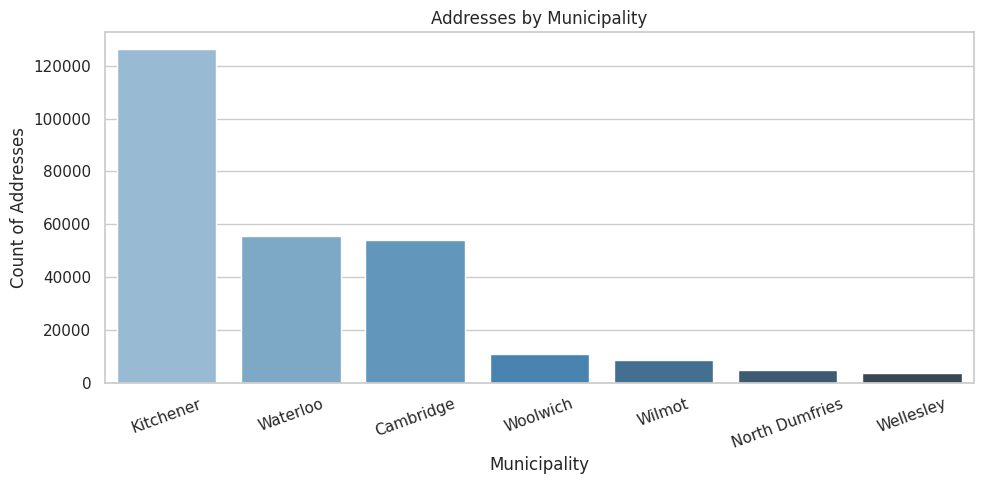

In [6]:
# Municipality counts
top_municipalities = analysis_df[municipality_col].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=top_municipalities.index, y=top_municipalities.values, hue=top_municipalities.index, dodge=False, palette="Blues_d", legend=False)
plt.title("Addresses by Municipality")
plt.xlabel("Municipality")
plt.ylabel("Count of Addresses")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


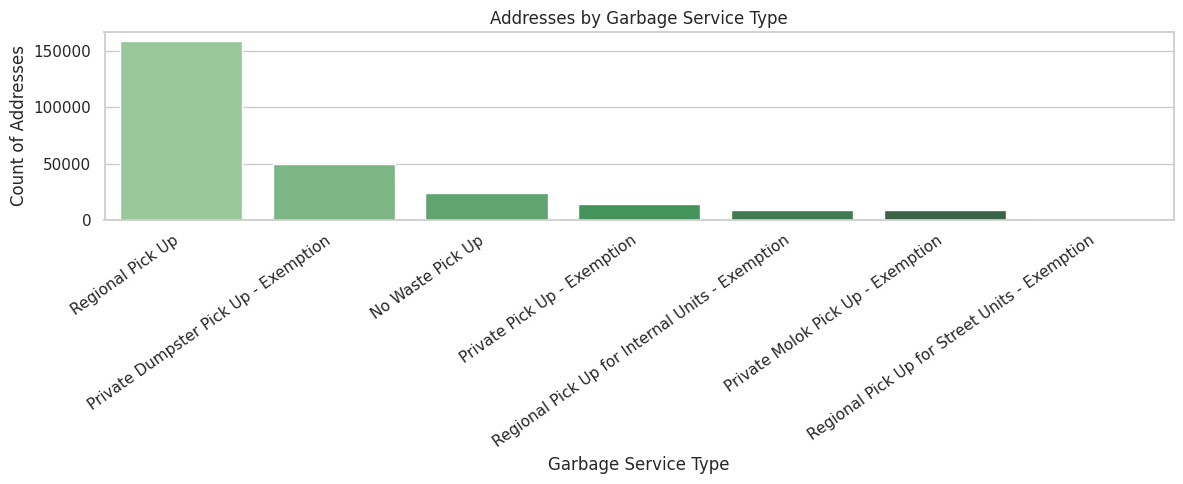

In [7]:
# Service type counts
top_services = analysis_df[service_col].value_counts()

plt.figure(figsize=(12,5))
sns.barplot(x=top_services.index, y=top_services.values, hue=top_services.index, dodge=False, palette="Greens_d", legend=False)
plt.title("Addresses by Garbage Service Type")
plt.xlabel("Garbage Service Type")
plt.ylabel("Count of Addresses")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


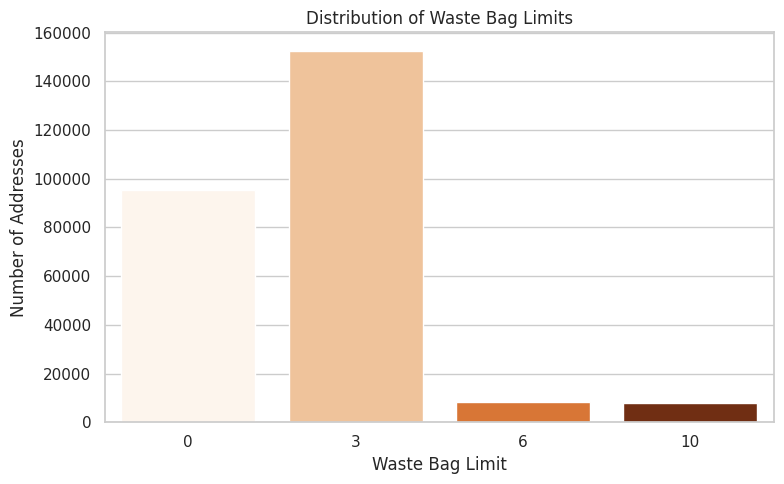

In [8]:
# Waste bag limit distribution
plt.figure(figsize=(8,5))
sns.countplot(data=analysis_df, x=bag_limit_col, hue=bag_limit_col, palette="Oranges", legend=False)
plt.title("Distribution of Waste Bag Limits")
plt.xlabel("Waste Bag Limit")
plt.ylabel("Number of Addresses")
plt.tight_layout()
plt.show()


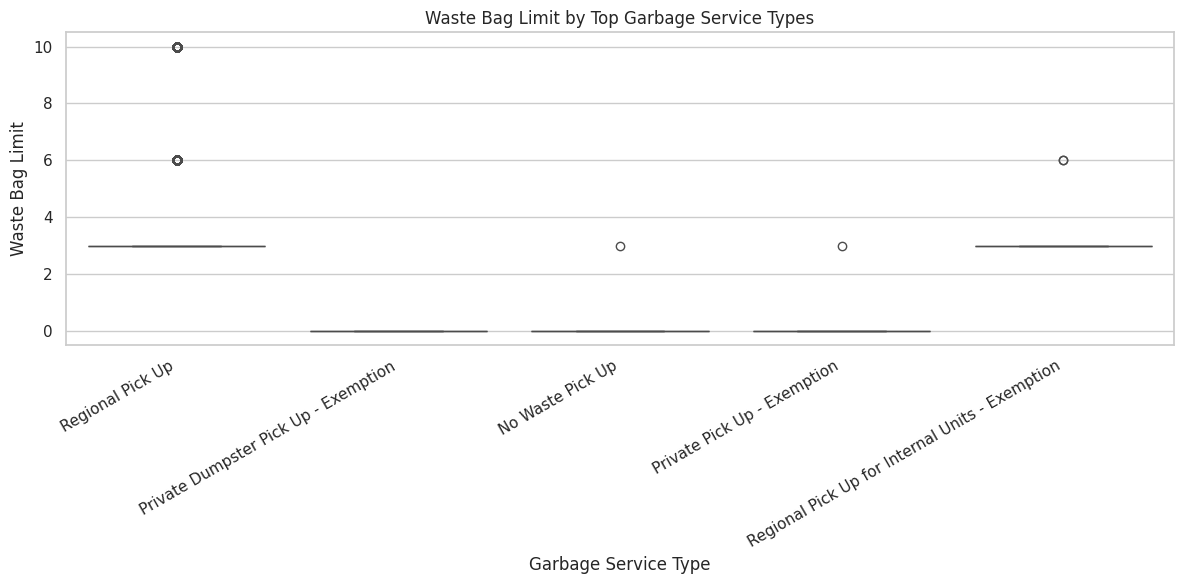

In [9]:
# Boxplot of bag limit by top service types
top_service_order = analysis_df[service_col].value_counts().head(5).index
service_subset = analysis_df[analysis_df[service_col].isin(top_service_order)].copy()

plt.figure(figsize=(12,6))
sns.boxplot(data=service_subset, x=service_col, y=bag_limit_col, order=top_service_order)
plt.title("Waste Bag Limit by Top Garbage Service Types")
plt.xlabel("Garbage Service Type")
plt.ylabel("Waste Bag Limit")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


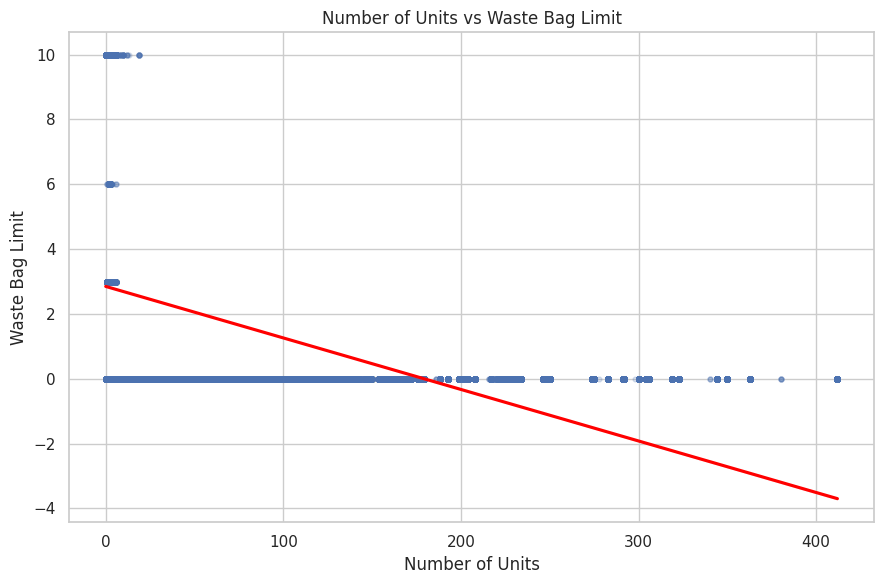

In [10]:
# Scatterplot and trend between NumberOfUnits and WasteBagLimit
scatter_sample = analysis_df[[units_col, bag_limit_col]].dropna()
scatter_sample = scatter_sample[scatter_sample[units_col] <= scatter_sample[units_col].quantile(0.99)]

plt.figure(figsize=(9,6))
sns.regplot(data=scatter_sample, x=units_col, y=bag_limit_col, scatter_kws={"alpha":0.2, "s":12}, line_kws={"color":"red"})
plt.title("Number of Units vs Waste Bag Limit")
plt.xlabel("Number of Units")
plt.ylabel("Waste Bag Limit")
plt.tight_layout()
plt.show()


## 4. Statistical Test 1 – Welch's t-test

### Why this test fits the case study
This test checks whether the **mean waste bag limit** differs between the **two most common garbage service types**.

That is important because if service types differ significantly in allowed waste capacity, then the region clearly has **different service conditions**, which supports the argument that **one uniform routing logic is inefficient**.

### Variables
- **Independent Variable:** Garbage service type
- **Dependent Variable:** Waste bag limit


In [11]:
# Welch's t-test between the two most common service types
top_two_services = analysis_df[service_col].value_counts().head(2).index.tolist()

group_a = analysis_df.loc[analysis_df[service_col] == top_two_services[0], bag_limit_col].dropna()
group_b = analysis_df.loc[analysis_df[service_col] == top_two_services[1], bag_limit_col].dropna()

t_stat, p_value_t = ttest_ind(group_a, group_b, equal_var=False)

print("Top two service types compared:")
print("Group A:", top_two_services[0], "| n =", len(group_a), "| mean =", round(group_a.mean(), 3))
print("Group B:", top_two_services[1], "| n =", len(group_b), "| mean =", round(group_b.mean(), 3))
print("\nWelch's t-test result")
print("t-statistic =", t_stat)
print("p-value =", p_value_t)


Top two service types compared:
Group A: Regional Pick Up | n = 158931 | mean = 3.495
Group B: Private Dumpster Pick Up - Exemption | n = 49468 | mean = 0.0

Welch's t-test result
t-statistic = 863.787729315808
p-value = 0.0


In [12]:
if p_value_t < 0.05:
    print("Interpretation: Reject the null hypothesis.")
    print("The mean waste bag limit differs significantly between the two most common garbage service types.")
else:
    print("Interpretation: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean waste bag limit between the two service types.")


Interpretation: Reject the null hypothesis.
The mean waste bag limit differs significantly between the two most common garbage service types.


## 5. Statistical Test 2 – Chi-square test of independence

### Why this test fits the case study
This test checks whether **municipality** and **garbage service type** are associated.

If they are associated, then service structure varies by municipality. That supports the business case that **static one-size-fits-all scheduling is not appropriate across the region**.

### Variables
- **Variable 1:** Municipality
- **Variable 2:** Garbage service type


In [13]:
contingency_table = pd.crosstab(analysis_df[municipality_col], analysis_df[service_col])
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print("Chi-square test of independence")
print("Chi-square statistic =", chi2)
print("Degrees of freedom =", dof)
print("p-value =", p_value_chi)

display(contingency_table)


Chi-square test of independence
Chi-square statistic = 23583.32070795732
Degrees of freedom = 36
p-value = 0.0


GarbageServiceType,No Waste Pick Up,Private Dumpster Pick Up - Exemption,Private Molok Pick Up - Exemption,Private Pick Up - Exemption,Regional Pick Up,Regional Pick Up for Internal Units - Exemption,Regional Pick Up for Street Units - Exemption
Municipality,,,,,,,
Cambridge,4639,4456,641,2412,39204,2505,114
Kitchener,12563,28443,6249,7329,67731,3686,313
North Dumfries,639,22,2,175,3892,19,0
Waterloo,3844,16182,1513,3132,29466,1431,73
Wellesley,346,16,0,61,3220,70,0
Wilmot,593,179,30,249,6470,1078,12
Woolwich,1445,170,4,151,8948,200,12


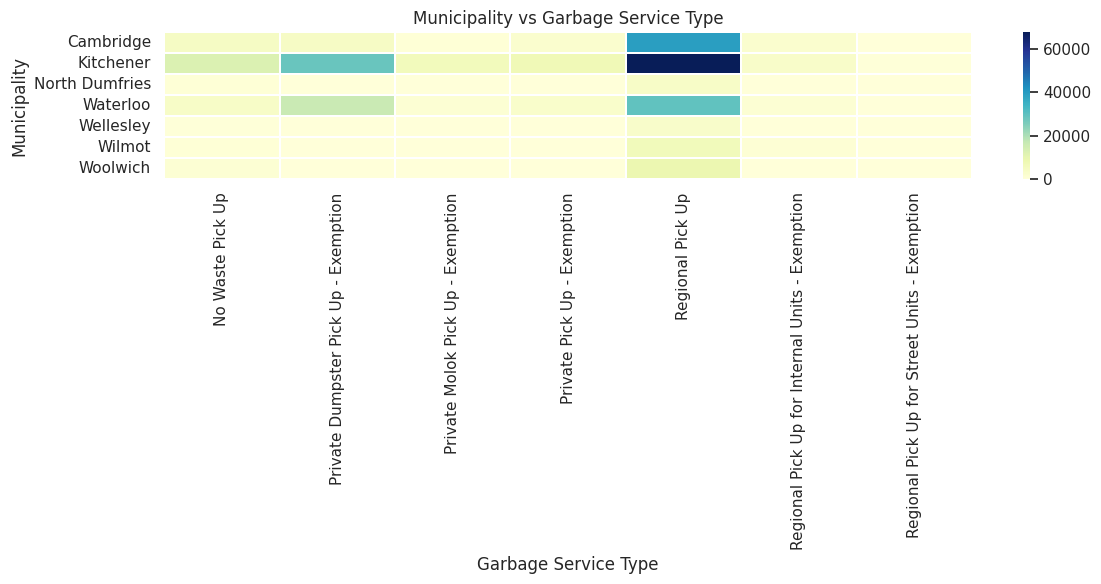

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(contingency_table, cmap="YlGnBu", linewidths=0.2)
plt.title("Municipality vs Garbage Service Type")
plt.xlabel("Garbage Service Type")
plt.ylabel("Municipality")
plt.tight_layout()
plt.show()


In [15]:
if p_value_chi < 0.05:
    print("Interpretation: Reject the null hypothesis.")
    print("Municipality and garbage service type are significantly associated.")
else:
    print("Interpretation: Fail to reject the null hypothesis.")
    print("Municipality and garbage service type are not significantly associated.")


Interpretation: Reject the null hypothesis.
Municipality and garbage service type are significantly associated.


## 6. Statistical Test 3 – Pearson correlation and simple linear regression

### Why this test fits the case study
This test checks whether the **number of units** is related to the **waste bag limit**.

This aligns with the case study because building structure and housing density are part of what drives waste collection demand. If the relationship is significant, it supports using **AI and data science to predict demand and optimize routes**.

### Variables
- **Independent Variable:** Number of units
- **Dependent Variable:** Waste bag limit


In [16]:
corr_df = analysis_df[[units_col, bag_limit_col]].dropna()

corr_value, p_value_corr = pearsonr(corr_df[units_col], corr_df[bag_limit_col])

print("Pearson correlation result")
print("Correlation coefficient =", corr_value)
print("p-value =", p_value_corr)


Pearson correlation result
Correlation coefficient = -0.483087800297753
p-value = 0.0


In [17]:
if p_value_corr < 0.05:
    print("Interpretation: Reject the null hypothesis.")
    direction = "positive" if corr_value > 0 else "negative"
    print(f"There is a statistically significant {direction} relationship between number of units and waste bag limit.")
else:
    print("Interpretation: Fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between number of units and waste bag limit.")


Interpretation: Reject the null hypothesis.
There is a statistically significant negative relationship between number of units and waste bag limit.


In [18]:
# Simple linear regression
reg_df = corr_df.copy()
X = reg_df[[units_col]]
y = reg_df[bag_limit_col]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

print("Linear Regression Results")
print("Intercept =", model.intercept_)
print("Coefficient =", model.coef_[0])
print("R-squared =", r2)


Linear Regression Results
Intercept = 2.769353685952752
Coefficient = -0.012199817819279741
R-squared = 0.23337382279652186


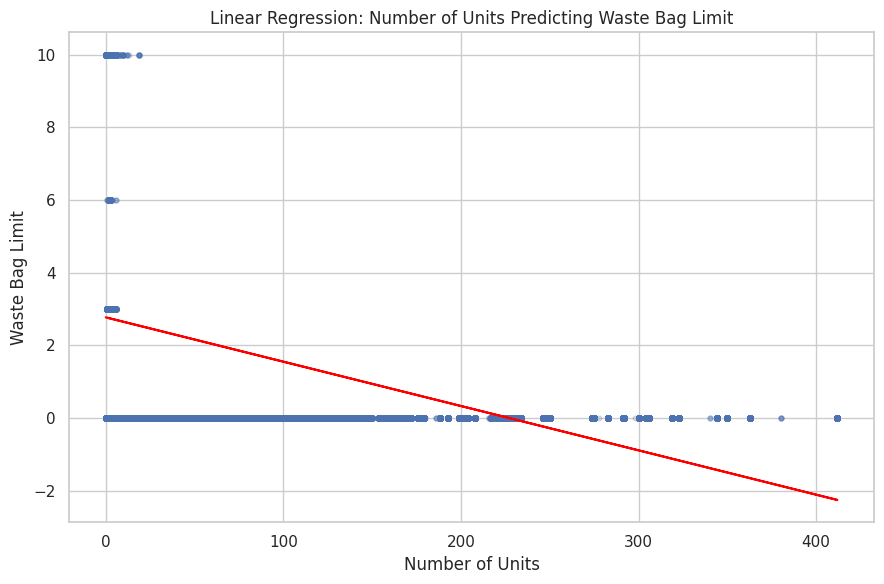

In [19]:
# Plot regression line on a trimmed sample for readability
plot_df = reg_df[reg_df[units_col] <= reg_df[units_col].quantile(0.99)].copy()
plot_pred = model.predict(plot_df[[units_col]])

plt.figure(figsize=(9,6))
plt.scatter(plot_df[units_col], plot_df[bag_limit_col], alpha=0.2, s=12)
plt.plot(plot_df[units_col], plot_pred, color="red")
plt.title("Linear Regression: Number of Units Predicting Waste Bag Limit")
plt.xlabel("Number of Units")
plt.ylabel("Waste Bag Limit")
plt.tight_layout()
plt.show()


## 7. Business interpretation of the findings

This is the most important part for the in-class activity: connect the analysis back to the business problem.

### What the tests suggest
1. **Welch's t-test** helps show that different service structures are associated with different waste capacity patterns.
2. **Chi-square** helps show that service structure varies by municipality.
3. **Correlation and regression** help show that property structure is related to waste capacity.

### Why that matters
Together, these results support the argument that **waste collection demand varies across the region**.  
That means a **static schedule is not ideal**, and a **predictive AI-based routing system** is a more defensible countermeasure.

### How this connects to the product idea
- **Experiment:** Analyze structural waste demand variability using address and service data
- **AI/ML Tool:** Use predictive analytics to estimate waste demand and optimize route planning
- **Product:** AI-driven demand-responsive municipal waste routing
- **Market:** Municipalities seeking lower cost, fewer overflow incidents, and better service reliability


## 8. Suggested 2-minute EDA explanation for the elevator pitch

**You can say this during your presentation:**

> We analyzed a dataset containing 263,929 waste collection addresses across the Region of Waterloo.  
> Our exploratory data analysis showed that Kitchener, Waterloo, and Cambridge account for the largest share of addresses, and that waste service structure varies considerably across the region.  
> We then used three statistical tests aligned with our case study.  
> First, a Welch's t-test showed that the average waste bag limit differs significantly between the two most common garbage service types, which means service conditions are not uniform.  
> Second, a Chi-square test showed a significant association between municipality and garbage service type, indicating that different municipalities operate under different service structures.  
> Third, Pearson correlation and linear regression showed a significant relationship between number of units and waste bag limit, meaning housing structure influences waste demand.  
> These findings support our business case that static waste collection scheduling is inefficient, and that AI-based demand-responsive routing is a more data-driven solution.


## 9. Presenter split suggestion

### Presenter 1
- Business problem
- TBP steps 1 to 5
- Welch's t-test

### Presenter 2
- EDA overview
- Chi-square test

### Presenter 3
- Correlation and regression
- AI/ML product explanation
